# Análise Inicial dos Dados **Crus** — Home Credit Default Risk

## Índice
- **Parte 0** — Setup e configuração
- **Parte 1** — `application_train`
- **Parte 2** — `previous_application`
- **Parte 3** — `bureau`
- **Parte 4** — `installments_payments`


---
## Parte 0 — Setup, configuração


In [1]:
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from utils import get_database_engine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

print("Bibliotecas carregadas.")

Bibliotecas carregadas.


In [2]:
engine = get_database_engine() # Engine do SQLAlchemy (detecta docker/local)

[CONEXÃO] Execução isolada detectada (Local/Notebook). Engine SQLAlchemy em 'postgres'.


### Funções de EDA


In [3]:
def separa_campos(df, ignora=("sk_id_curr",)):
    # Separa colunas em quantitativas (int/float) e qualitativas (resto), ignorando chaves.
    quanti, quali = [], []
    for col in df.columns:
        if col in ignora:
            continue
        tipo = df[col].dtype.name
        (quanti if ("int" in tipo or "float" in tipo) else quali).append(col)
    return quanti, quali


def correlacao_pearson_target(df, cols, target="target", head=15, tail=15):
    corr = df[cols].corr(method="pearson")[target].sort_values(ascending=False)
    if head:
        print("Maiores correlacoes diretas:\n", corr.head(head), "\n")
    if tail:
        print("Maiores correlacoes inversas:\n", corr.tail(tail).sort_values(), "\n")
    return corr


def cramers_v(df, col, target="target"):
    # Cramer's V entre uma variavel categorica e o target (associacao 0..1).
    tabela = pd.crosstab(df[col], df[target])
    chi2 = chi2_contingency(tabela)[0]
    n = tabela.to_numpy().sum()
    r, k = tabela.shape
    return np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1))


def value_counts_e_nulos(df, col):
    print(df[col].value_counts(dropna=False))
    print(f"Nulos em '{col}': {df[col].isna().sum()}")


def kde_por_target(df, col, ax, xlabel=None, clip=None):
    kw = dict(fill=True) if clip is None else dict(fill=True, clip=clip)
    sns.kdeplot(df.loc[df["target"] == 0, col], label="Adimplente (0)", color="g", ax=ax, **kw)
    sns.kdeplot(df.loc[df["target"] == 1, col], label="Inadimplente (1)", color="r", ax=ax, **kw)
    ax.set_title(f"{col} por status de pagamento", fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel or col); ax.set_ylabel("Densidade"); ax.legend()


def taxa_inadimplencia_por_categoria(df, col, target="target", min_count=200, top=None):
    g = df.groupby(col, observed=True)[target].agg(total="count", taxa="mean")
    g = g[g["total"] >= min_count].sort_values("taxa", ascending=False)
    g["taxa_pct"] = (g["taxa"] * 100).round(2)
    if top:
        g = g.head(top)
    plt.figure(figsize=(9, max(3, 0.4 * len(g))))
    ax = sns.barplot(x=g["taxa_pct"], y=g.index, color="indianred")
    media = df[target].mean() * 100
    ax.axvline(media, color="black", linestyle="--", label=f"media geral ({media:.1f}%)")
    ax.set_title(f"Taxa de inadimplencia por {col}", fontweight="bold")
    ax.set_xlabel("Inadimplencia (%)"); ax.set_ylabel(col); ax.legend()
    for c in ax.containers:
        ax.bar_label(c, fmt="%.1f%%", padding=3)
    plt.tight_layout(); plt.show()


def calcula_woe_iv(df, feature, target="target", bins=10):
    d = df[[feature, target]].copy()
    if pd.api.types.is_numeric_dtype(d[feature]) and d[feature].nunique() > bins:
        d["faixa"] = pd.qcut(d[feature], q=bins, duplicates="drop")
    else:
        d["faixa"] = d[feature].astype("object").fillna("Missing")
    grp = d.groupby("faixa", observed=True)[target].agg(total="count", bad="sum")
    grp["good"] = grp["total"] - grp["bad"]
    eps = 0.5  # suavizacao para evitar log(0)
    dist_bad = (grp["bad"] + eps) / (grp["bad"].sum() + eps)
    dist_good = (grp["good"] + eps) / (grp["good"].sum() + eps)
    grp["woe"] = np.log(dist_good / dist_bad)
    grp["iv"] = (dist_good - dist_bad) * grp["woe"]
    return grp, grp["iv"].sum()

print("Utilitarios definidos.")

Utilitarios definidos.


---
## Parte 1 — `application_train` (dados crus)

Tabela principal: **1 linha por cliente** (`sk_id_curr`) e a variável-alvo `target` (1 = inadimplente).


In [4]:
print("Carregando application_train (cru) do PostgreSQL...")
df_app = pd.read_sql("SELECT * FROM application_train", engine)
print(f"Linhas: {df_app.shape[0]:,} | Colunas: {df_app.shape[1]}")
df_app.head()

Carregando application_train (cru) do PostgreSQL...
Linhas: 307,511 | Colunas: 122


,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### 1.1 — Qualidade da base: nulos, duplicatas e colunas constantes

In [5]:
# Panorama global de valores ausentes
nulos = (df_app.isna().mean() * 100).sort_values(ascending=False)
nulos = nulos[nulos > 0].round(2)
print(f"{len(nulos)} de {df_app.shape[1]} colunas tem valores ausentes. Top 20:")
print(nulos.head(20).to_frame("% nulos"))

print("\nLinhas totalmente duplicadas:", int(df_app.duplicated().sum()))
print("sk_id_curr duplicados:", int(df_app["sk_id_curr"].duplicated().sum()))
nunique = df_app.nunique(dropna=False)
constantes = nunique[nunique <= 1].index.tolist()
print("Colunas constantes:", constantes if constantes else "nenhuma")

67 de 122 colunas tem valores ausentes. Top 20:
                          % nulos
commonarea_medi             69.87
commonarea_avg              69.87
commonarea_mode             69.87
nonlivingapartments_mode    69.43
nonlivingapartments_avg     69.43
nonlivingapartments_medi    69.43
fondkapremont_mode          68.39
livingapartments_mode       68.35
livingapartments_avg        68.35
livingapartments_medi       68.35
floorsmin_avg               67.85
floorsmin_mode              67.85
floorsmin_medi              67.85
years_build_medi            66.50
years_build_mode            66.50
years_build_avg             66.50
own_car_age                 65.99
landarea_medi               59.38
landarea_mode               59.38
landarea_avg                59.38

Linhas totalmente duplicadas: 0
sk_id_curr duplicados: 0
Colunas constantes: nenhuma


> **Análise**
> - O pior bloco de nulos (~66–70%) são as características do imóvel (`commonarea_*`, `nonlivingapartments_*`, …)
>   e `own_car_age` (66%). Sem duplicatas, sem `sk_id_curr` repetido, sem colunas constantes.
>
> **Tratamento**
> - **Descartar** o bloco de imóvel (majoritariamente vazio — imputar só adicionaria ruído).
> - `own_car_age` 66% nulo é, na prática, "não tem carro" — separar **ausência** de **valor** criando um
>   flag `has_car` e imputando idade só para quem tem carro.
>
> **ABT**
> - `has_car` como feature nova.


### 1.2 — Variável alvo (`target`) e desbalanceamento

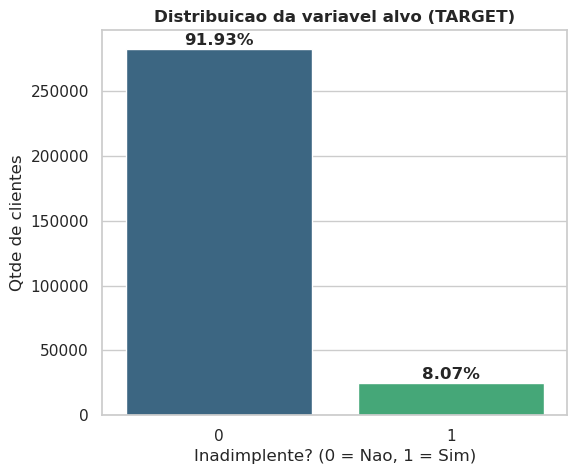

Adimplentes: 91.93% | Inadimplentes: 8.07%


In [6]:
target_pct = df_app["target"].value_counts(normalize=True) * 100
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="target", data=df_app, hue="target", palette="viridis", legend=False)
plt.title("Distribuicao da variavel alvo (TARGET)", fontweight="bold")
plt.xlabel("Inadimplente? (0 = Nao, 1 = Sim)"); plt.ylabel("Qtde de clientes")
for p in ax.patches:
    ax.annotate(f"{p.get_height()/len(df_app)*100:.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="center", xytext=(0, 6), textcoords="offset points", fontweight="bold")
plt.show()
print(f"Adimplentes: {target_pct[0]:.2f}% | Inadimplentes: {target_pct[1]:.2f}%")

> **Análise**
> - **8% de inadimplentes** vs 92% adimplentes (~1:11). Classe fortemente **desbalanceada**.
>
> **Modelagem** — acurácia é enganosa (um modelo que "chuta que todos pagam" acerta 92%).


### 1.3 — Correlação das variáveis **numéricas** com o target (Pearson)

In [7]:
quanti, quali = separa_campos(df_app, ignora=("sk_id_curr", "target"))
# inclui target no calculo
_ = correlacao_pearson_target(df_app, ["target"] + quanti, head=15, tail=15)

Maiores correlacoes diretas:
 target                         1.000000
days_birth                     0.078239
region_rating_client_w_city    0.060893
region_rating_client           0.058899
days_last_phone_change         0.055218
days_id_publish                0.051457
reg_city_not_work_city         0.050994
flag_emp_phone                 0.045982
reg_city_not_live_city         0.044395
flag_document_3                0.044346
days_registration              0.041975
own_car_age                    0.037612
live_city_not_work_city        0.032518
def_30_cnt_social_circle       0.032248
def_60_cnt_social_circle       0.031276
Name: target, dtype: float64 

Maiores correlacoes inversas:
 ext_source_3                 -0.178919
ext_source_2                 -0.160472
ext_source_1                 -0.155317
days_employed                -0.044932
floorsmax_avg                -0.044003
floorsmax_medi               -0.043768
floorsmax_mode               -0.043226
amt_goods_price              -0.039

> **Análise**
> - Correlações lineares individuais **fracas**. As maiores são os scores externos
>   `ext_source_3/2/1` (~−0,16 a −0,18).


### 1.4 — Variáveis **categóricas**: associação (Cramér's V) e risco por categoria

In [8]:
registros = [{"col": col, "cramers_v": cramers_v(df_app, col)} for col in quali]
df_cramers = pd.DataFrame(registros).sort_values("cramers_v", ascending=False)
print(df_cramers.head(15).to_string(index=False))

                       col  cramers_v
           occupation_type   0.081516
         organization_type   0.072340
          name_income_type   0.063845
       name_education_type   0.057571
               code_gender   0.054721
        name_family_status   0.040512
         name_housing_type   0.036981
        name_contract_type   0.030876
        wallsmaterial_mode   0.030349
              flag_own_car   0.021838
            housetype_mode   0.013430
        fondkapremont_mode   0.013150
       emergencystate_mode   0.012099
           name_type_suite   0.010354
weekday_appr_process_start   0.007074


In [9]:
for col in ["occupation_type", "organization_type", "name_income_type",
            "name_education_type", "code_gender"]:
    print("=" * 60)
    value_counts_e_nulos(df_app, col)

occupation_type
None                     96391
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64
Nulos em 'occupation_type': 96391
organization_type
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               68

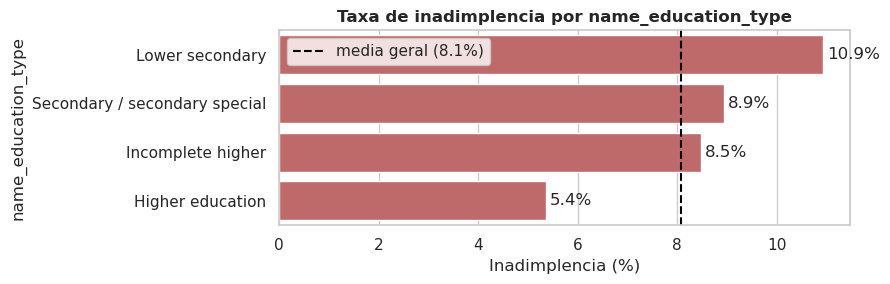

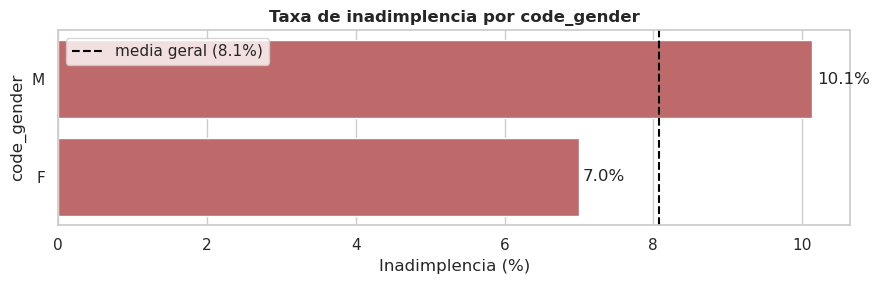

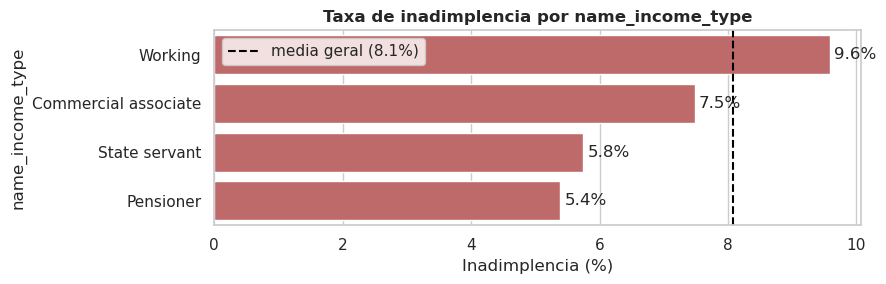

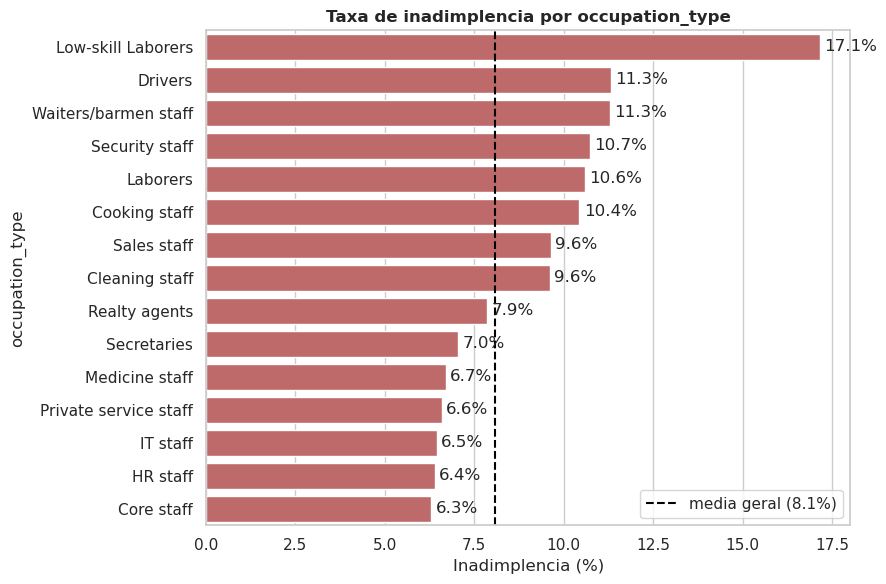

In [10]:
for col in ["name_education_type", "code_gender", "name_income_type", "occupation_type"]:
    taxa_inadimplencia_por_categoria(df_app, col, top=15)

> **Análise**
> - Mais associadas ao target: `occupation_type`, `organization_type`, `name_income_type`,
>   `name_education_type`, `code_gender` (Cramér's V ~0,05–0,08). As demais (`flag_own_realty`, `weekday...`)
>   são desprezíveis.
> - Alta cardinalidade e categorias raras: `organization_type` tem 58 categorias (com `XNA`);
>   `occupation_type` tem 31% de nulos; `name_income_type` tem categorias minúsculas (Businessman=10).
> - Risco por categoria vira gradiente claro: escolaridade *Lower secondary* ~11% → *Higher education* ~5%;
>   ocupação *Low-skill Laborers* ~17% (topo).
>
> **Tratamento**
> - Nulos categóricos → `'Unknown'`; categorias com frequência `< min_freq` (ex.: 500) → `'Other_low_freq'`;
>   `XNA` em `code_gender` → `'Unknown'`.
>
> **ABT**
> - Manter as **5 categóricas** de maior associação; descartar as de associação ~0.
> - **fairness:** `code_gender` e `occupation_type` são sensíveis.


### 1.5 — Demografia: idade e a anomalia de `DAYS_EMPLOYED`

Clientes com days_employed = 365243 (anomalia): 55374 (18.0%)

Idade (anos):
count    307511.00
mean         43.91
std          11.95
min          20.50
25%          33.98
50%          43.12
75%          53.89
max          69.07
Name: days_birth, dtype: float64


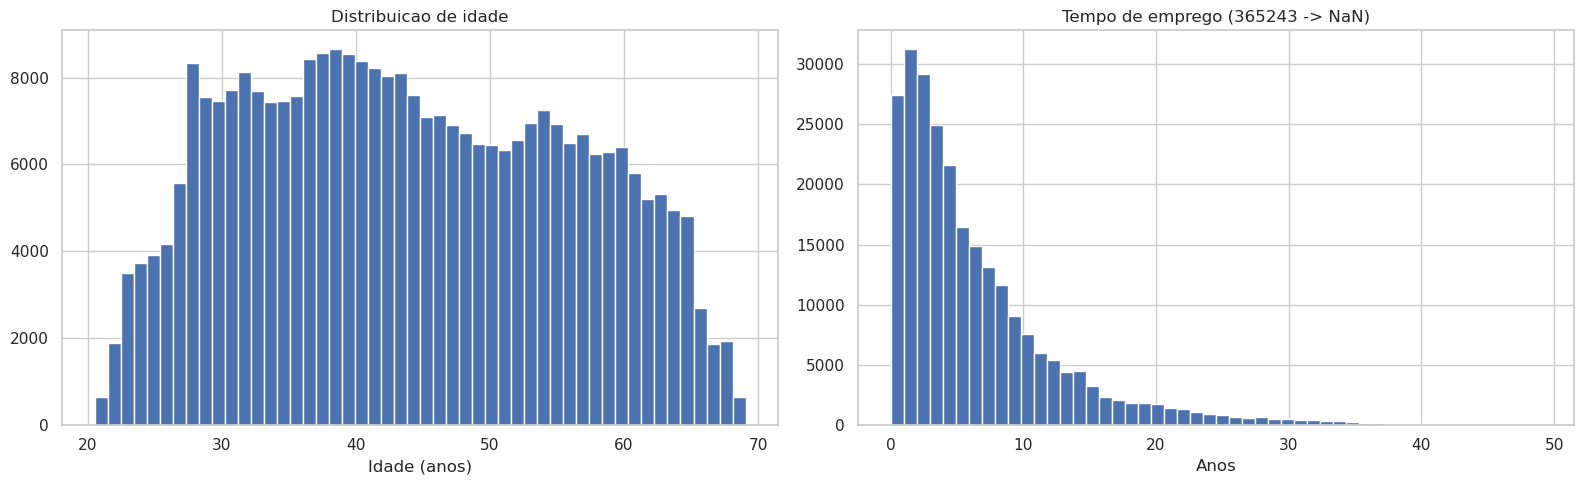

Taxa de inadimplencia por faixa etaria (%):
days_birth
(20, 30]    11.44
(30, 40]     9.59
(40, 50]     7.64
(50, 60]     6.12
(60, 70]     4.92
Name: target, dtype: float64


In [11]:
idade = np.abs(df_app["days_birth"]) / 365.25
anom = (df_app["days_employed"] == 365243)
_days_emp = df_app["days_employed"].replace({365243: np.nan})
anos_emp = np.abs(_days_emp) / 365.25

print("Clientes com days_employed = 365243 (anomalia):", int(anom.sum()),
      f"({anom.mean()*100:.1f}%)")
print("\nIdade (anos):"); print(idade.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
idade.hist(bins=50, ax=axes[0]); axes[0].set_title("Distribuicao de idade"); axes[0].set_xlabel("Idade (anos)")
anos_emp.hist(bins=50, ax=axes[1]); axes[1].set_title("Tempo de emprego (365243 -> NaN)"); axes[1].set_xlabel("Anos")
plt.tight_layout(); plt.show()

faixa = pd.cut(idade, bins=[20, 30, 40, 50, 60, 70])
print("Taxa de inadimplencia por faixa etaria (%):")
print((df_app.groupby(faixa, observed=True)["target"].mean() * 100).round(2))

> **Análise**
> - `days_birth`/`days_employed` vêm em **dias negativos**. `days_employed == 365243` (~1000 anos) é um
>   **código de ausência** de vínculo (aposentados): ~18% da base.
> - Inadimplência **cai com a idade**: 20-30 anos ~11% → 60-70 anos ~5% (relação forte e bem-comportada).
>
> **Tratamento**
> - Converter `days_birth` → `age` (anos) e `days_employed` → `years_employed` (anos), tratando `365243`
>   como nulo (senão distorce demais).
>
> **ABT**
> - `age` e `years_employed`; **flag `days_employed_anom`**.


### 1.6 — Fontes externas de score (`EXT_SOURCE_1/2/3`)

% de ausentes:
ext_source_1    56.38
ext_source_2     0.21
ext_source_3    19.83
dtype: float64


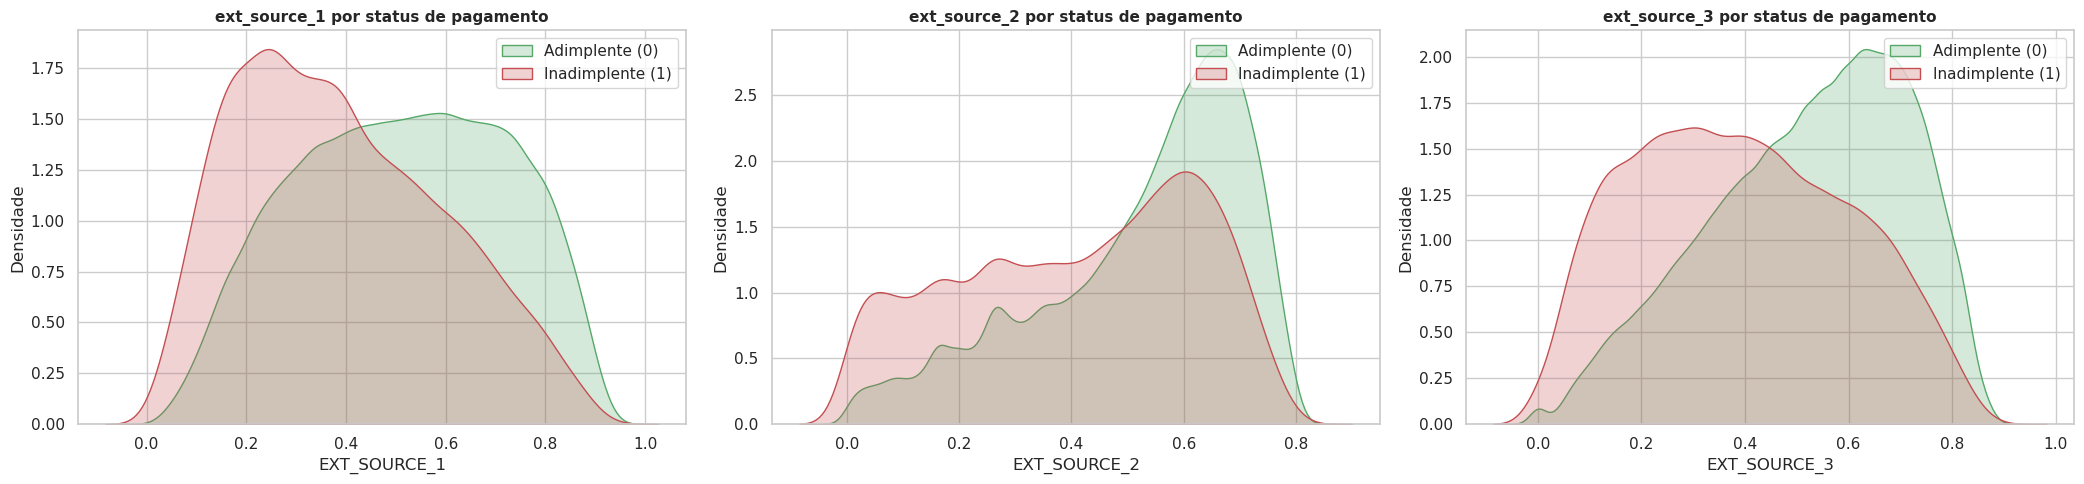

Correlacao com target -> ext_source_mean: -0.2221


In [12]:
ext = ["ext_source_1", "ext_source_2", "ext_source_3"]
print("% de ausentes:"); print((df_app[ext].isna().mean() * 100).round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for a, c in zip(axes, ext):
    kde_por_target(df_app.dropna(subset=[c]), c, a, c.upper())
plt.tight_layout(); plt.show()

ext_mean = df_app[ext].mean(axis=1)
comp = pd.concat([df_app["target"], ext_mean.rename("ext_source_mean")], axis=1)
print("Correlacao com target -> ext_source_mean:", round(comp.corr()["target"]["ext_source_mean"], 4))

> **Análise**
> - Os scores externos são dos **preditores mais fortes** da base, mas também os mais incompletos
>   (`ext_source_1` ~56% nulo, `ext_source_3` ~20%, `ext_source_2` ~0,2%).
> - A **média combinada** dos três (`ext_source_mean`) fica **mais forte** (correlação ~−0,22) do que
>   qualquer score isolado — e é robusta à ausência de um deles.
>
> **Tratamento**
> - **Não descartar** `ext_source_1/3` por causa dos nulos; **imputar** (mediana).
>
> **ABT**
> - `ext_source_1/2/3` imputados **+** a feature derivada `ext_source_mean` (o preditor mais forte).


### 1.7 — Variáveis monetárias: outliers

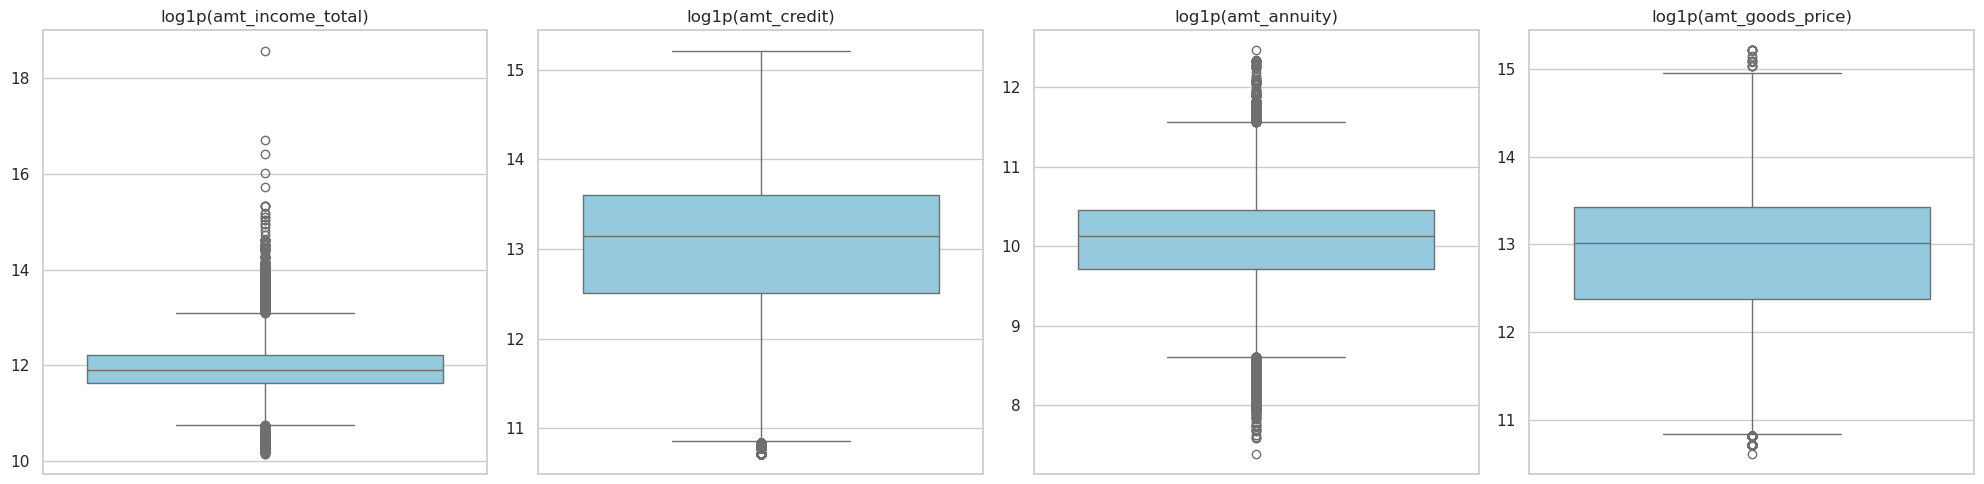

Percentis altos (checar extremos):
       amt_income_total  amt_credit  amt_annuity  amt_goods_price
0.500          147150.0    513531.0      24903.0         450000.0
0.950          337500.0   1350000.0      53325.0        1305000.0
0.990          472500.0   1854000.0      70006.0        1800000.0
0.999          900000.0   2517300.0     110048.0        2250000.0
1.000       117000000.0   4050000.0     258026.0        4050000.0

Correlacao das razoes com o target:
fe_credit_income    -0.0077
fe_annuity_income    0.0143
Name: target, dtype: float64


In [13]:
mon = ["amt_income_total", "amt_credit", "amt_annuity", "amt_goods_price"]
fig, axes = plt.subplots(1, len(mon), figsize=(20, 5))
for a, c in zip(axes, mon):
    sns.boxplot(y=np.log1p(df_app[c].dropna()), ax=a, color="skyblue")
    a.set_title(f"log1p({c})"); a.set_ylabel("")
plt.tight_layout(); plt.show()

print("Percentis altos (checar extremos):")
print(df_app[mon].quantile([0.5, 0.95, 0.99, 0.999, 1.0]).round(0))

# Razoes de comprometimento (exploracao)
r_credit = df_app["amt_credit"] / df_app["amt_income_total"].replace(0, np.nan)
r_annuity = df_app["amt_annuity"] / df_app["amt_income_total"].replace(0, np.nan)
comp = pd.concat([df_app["target"], r_credit.rename("fe_credit_income"),
                  r_annuity.rename("fe_annuity_income")], axis=1)
print("\nCorrelacao das razoes com o target:")
print(comp.corr()["target"].drop("target").round(4))

> **Análise**
> - `amt_income_total` chega a **117.000.000** no máximo vs 472.500 no p99 (~250x) — outliers extremos
>   (renda declarada altíssima; possível erro/atípico) que distorcem médias e modelos sensíveis a escala.
> - As **razões de comprometimento** (crédito/renda, anuidade/renda) discriminam **muito pouco** o target.
>
> **Tratamento**
> - **Winsorizar/clip** `amt_income_total` (ex.: no p99); tratar renda 0/ausente (imputar mediana).
>
> **ABT**
> - Razões `fe_credit_income_percent` e `fe_annuity_income_percent` entram mais por **completude** que por
>   poder preditivo (sinal fraco — expectativa baixa, deixar o modelo decidir).


### 1.8 — Força preditiva (WOE/IV) e multicolinearidade

In [14]:
# WOE/IV (metrica-padrao de risco de credito). Usa colunas cruas + derivadas exploratorias.
df_app["_ext_source_mean"] = df_app[ext].mean(axis=1)
df_app["_age"] = np.abs(df_app["days_birth"]) / 365.25
df_app["_fe_annuity_income"] = df_app["amt_annuity"] / df_app["amt_income_total"].replace(0, np.nan)

features_iv = ["_ext_source_mean", "ext_source_2", "_age",
               "_fe_annuity_income", "amt_credit", "name_education_type",
               "code_gender", "occupation_type", "cnt_fam_members"]
iv_scores = []
for f in features_iv:
    try:
        _, iv = calcula_woe_iv(df_app, f)
        iv_scores.append({"feature": f, "IV": round(iv, 4)})
    except Exception as e:
        iv_scores.append({"feature": f, "IV": f"erro: {e}"})
print(pd.DataFrame(iv_scores).sort_values(
    "IV", ascending=False, key=lambda s: pd.to_numeric(s, errors="coerce")).to_string(index=False))

            feature     IV
   _ext_source_mean 0.6085
       ext_source_2 0.3070
               _age 0.0842
    occupation_type 0.0828
name_education_type 0.0507
         amt_credit 0.0451
        code_gender 0.0386
 _fe_annuity_income 0.0059
    cnt_fam_members 0.0032


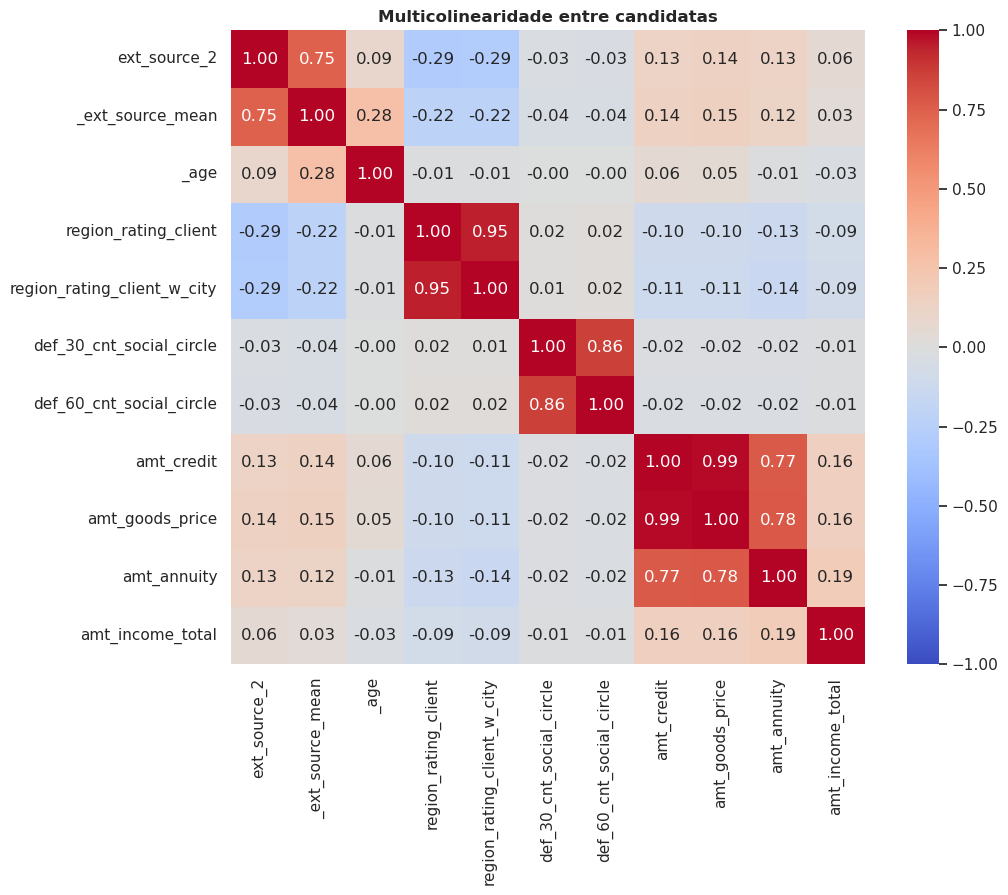

Pares com |correlacao| > 0.8 (candidatos a remover um dos dois):
region_rating_client      region_rating_client_w_city    0.951
def_30_cnt_social_circle  def_60_cnt_social_circle       0.861
amt_credit                amt_goods_price                0.987


In [15]:
# Multicolinearidade entre candidatas numericas (identifica pares redundantes)
cand = ["ext_source_2", "_ext_source_mean", "_age",
        "region_rating_client", "region_rating_client_w_city",
        "def_30_cnt_social_circle", "def_60_cnt_social_circle",
        "amt_credit", "amt_goods_price", "amt_annuity", "amt_income_total"]
cand = [c for c in cand if c in df_app.columns]
corr = df_app[cand].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Multicolinearidade entre candidatas", fontweight="bold")
plt.tight_layout(); plt.show()

pares = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Pares com |correlacao| > 0.8 (candidatos a remover um dos dois):")
print(pares[pares.abs() > 0.8].round(3).to_string())

> **Análise**
> - **IV**: `ext_source_mean` muito forte (>0,5 — legítimo, é um score de crédito, não vazamento),
>   `ext_source_2` forte; idade/ocupação medianos; razões financeiras e `cnt_fam_members` ~inúteis (<0,02).
> - Pares **altamente redundantes**: `region_rating_client` × `_w_city` (0,95), `def_30` × `def_60` (0,86),
>   `amt_credit` × `amt_goods_price` (0,99).
>
> **Tratamento**
> - Manter **apenas uma** de cada par redundante (ex.: `region_rating_client_w_city`,
>   `def_60_cnt_social_circle`, `amt_credit`) — enxuga o modelo sem perder informação.
>
> **ABT**
> - Cortar features com **IV < 0,02** (razões financeiras, nº de familiares) — entram só por completude.


---
## Parte 2 — `previous_application`

Histórico de **pedidos de crédito anteriores** do cliente. Granularidade de 1 linha
por **pedido** (`sk_id_prev`) → precisa ser **agregado por cliente** (`sk_id_curr`) para entrar na ABT.


In [16]:
q_prev_agg = """
SELECT
    sk_id_curr,
    COUNT(sk_id_prev)                                                  AS prev_contract_count,
    SUM(CASE WHEN name_contract_status = 'Refused'  THEN 1 ELSE 0 END) AS prev_refused_count,
    SUM(CASE WHEN name_contract_status = 'Approved' THEN 1 ELSE 0 END) AS prev_approved_count,
    AVG(amt_application)  AS prev_avg_amt_application,
    AVG(cnt_payment)      AS prev_avg_cnt_payment,
    MAX(days_decision)    AS prev_last_days_decision
FROM previous_application
GROUP BY sk_id_curr
"""
df_prev_agg = pd.read_sql(q_prev_agg, engine)
df_prev_agg["prev_refused_rate"] = df_prev_agg["prev_refused_count"] / df_prev_agg["prev_contract_count"]
print(f"Agregado: {df_prev_agg.shape[0]:,} clientes")


cand_prev = ["prev_contract_count", "prev_refused_count", "prev_approved_count",
             "prev_avg_amt_application", "prev_avg_cnt_payment",
             "prev_last_days_decision", "prev_refused_rate"]
tmp = df_app.merge(df_prev_agg, on="sk_id_curr", how="left")
print("\nCorrelacao das candidatas de previous_application com o target:")
print(tmp[cand_prev + ["target"]].corr()["target"].drop("target").sort_values(ascending=False).round(4))

Agregado: 338,857 clientes

Correlacao das candidatas de previous_application com o target:
prev_refused_rate           0.0777
prev_refused_count          0.0645
prev_avg_cnt_payment        0.0277
prev_contract_count         0.0198
prev_last_days_decision     0.0164
prev_avg_amt_application   -0.0218
prev_approved_count        -0.0316
Name: target, dtype: float64


> **Análise**

> - Entre as agregadas, a de maior sinal é `prev_refused_rate` (~0,08): quem **já foi recusado** antes tende a
>   ser mais arriscado. As contagens absolutas isoladas são mais fracas.
>
> **Tratamento**
> - Padronizar `name_contract_status`; a agregação já lida com valores ausentes via `0`.
>
> **ABT**
> - `prev_refused_rate` (normalizada pelo nº de pedidos) **+ flag `has_prev_app`** (ausência de histórico é
>   informação); imputar a taxa média para quem não tem histórico. Descartar as contagens fracas.


---
## Parte 3 — `bureau`

Créditos do cliente em **outras instituições**, reportados por bureaus de crédito.1 crédito
por linha. **Agregação por
cliente**.


In [17]:
q_bureau_agg = """
SELECT
    sk_id_curr,
    COUNT(sk_id_bureau)                                                  AS bureau_credit_count,
    SUM(CASE WHEN TRIM(credit_active) = 'Active' THEN 1 ELSE 0 END)      AS bureau_active_count,
    SUM(CASE WHEN TRIM(credit_active) = 'Closed' THEN 1 ELSE 0 END)      AS bureau_closed_count,
    AVG(days_credit)                                                     AS bureau_avg_days_credit,
    MAX(days_credit)                                                     AS bureau_last_days_credit,
    SUM(COALESCE(amt_credit_sum, 0))                                     AS bureau_total_credit,
    SUM(COALESCE(amt_credit_sum_debt, 0))                                AS bureau_total_debt,
    SUM(CASE WHEN COALESCE(credit_day_overdue, 0) > 0 THEN 1 ELSE 0 END) AS bureau_overdue_count
FROM bureau
GROUP BY sk_id_curr
"""
df_bureau_agg = pd.read_sql(q_bureau_agg, engine)
df_bureau_agg["bureau_active_rate"] = df_bureau_agg["bureau_active_count"] / df_bureau_agg["bureau_credit_count"]
df_bureau_agg["bureau_closed_rate"] = df_bureau_agg["bureau_closed_count"] / df_bureau_agg["bureau_credit_count"]
df_bureau_agg["bureau_debt_credit_ratio"] = (
    df_bureau_agg["bureau_total_debt"] / df_bureau_agg["bureau_total_credit"].replace(0, np.nan)
).fillna(0).clip(-1, 1)
print(f"Agregado: {df_bureau_agg.shape[0]:,} clientes")


cand_bureau = ["bureau_credit_count", "bureau_active_rate", "bureau_closed_rate",
               "bureau_avg_days_credit", "bureau_last_days_credit",
               "bureau_debt_credit_ratio", "bureau_overdue_count"]
tmp = df_app.merge(df_bureau_agg, on="sk_id_curr", how="left")
tmp[cand_bureau] = tmp[cand_bureau].fillna(0)
print("\nCorrelacao das candidatas de bureau com o target:")
print(tmp[cand_bureau + ["target"]].corr()["target"].drop("target").sort_values(ascending=False).round(4))

Agregado: 305,811 clientes

Correlacao das candidatas de bureau com o target:
bureau_avg_days_credit      0.0840
bureau_debt_credit_ratio    0.0676
bureau_last_days_credit     0.0527
bureau_active_rate          0.0487
bureau_overdue_count        0.0368
bureau_credit_count        -0.0100
bureau_closed_rate         -0.0765
Name: target, dtype: float64


> **Análise**
> - O sinal do bureau vem mais de **recência/atividade** (`avg_days_credit`, `closed_rate`) do que dos valores
>   em atraso; poder preditivo marginal **modesto** (~0,07-0,08), parecido com o de `previous_application`.
>
> **ABT**
> - Features de recência/atividade + `bureau_debt_credit_ratio` e `bureau_overdue_count`, **+ flag `has_bureau`**.


---
## Parte 4 — `installments_payments`

Comportamento de **pagamento de parcelas** de contratos anteriores.


In [18]:
q_inst_agg = """
WITH base AS (
    SELECT
        sk_id_curr,
        sk_id_prev,
        (days_entry_payment - days_instalment)                                AS days_late,
        CASE WHEN (days_entry_payment - days_instalment) > 0 THEN 1 ELSE 0 END AS is_late,
        CASE WHEN amt_payment < NULLIF(amt_instalment, 0) THEN 1 ELSE 0 END    AS is_underpaid
    FROM installments_payments
    WHERE sk_id_curr IS NOT NULL AND sk_id_prev IS NOT NULL
      AND days_instalment IS NOT NULL AND amt_instalment IS NOT NULL
)
SELECT
    sk_id_curr,
    COUNT(*)                     AS inst_payment_count,
    AVG(is_late::float)          AS inst_late_payment_rate,
    AVG(is_underpaid::float)     AS inst_underpayment_rate,
    AVG(days_late)               AS inst_avg_days_late,
    MAX(days_late)               AS inst_max_days_late
FROM base
GROUP BY sk_id_curr
"""
df_inst_agg = pd.read_sql(q_inst_agg, engine)
print(f"Agregado: {df_inst_agg.shape[0]:,} clientes")

cand_inst = ["inst_payment_count", "inst_late_payment_rate", "inst_underpayment_rate",
             "inst_avg_days_late", "inst_max_days_late"]
tmp = df_app.merge(df_inst_agg, on="sk_id_curr", how="left")
tmp["has_installments_history"] = tmp[cand_inst].notna().any(axis=1).astype(int)
tmp[cand_inst] = tmp[cand_inst].fillna(0)
print("\nCorrelacao das candidatas de installments com o target:")
print(tmp[cand_inst + ["has_installments_history", "target"]].corr()["target"]
      .drop("target").sort_values(ascending=False).round(4))

# Risco por faixa de atraso
faixa = pd.cut(tmp["inst_late_payment_rate"], bins=[-0.001, 0, 0.05, 0.10, 0.25, 0.50, 1.00])
print("\nTaxa de inadimplencia por faixa de taxa de atraso (%):")
print((tmp.groupby(faixa, observed=True)["target"].mean() * 100).round(2))

Agregado: 339,587 clientes

Correlacao das candidatas de installments com o target:
inst_late_payment_rate      0.0705
inst_underpayment_rate      0.0631
has_installments_history    0.0179
inst_avg_days_late          0.0167
inst_max_days_late          0.0052
inst_payment_count         -0.0163
Name: target, dtype: float64

Taxa de inadimplencia por faixa de taxa de atraso (%):
inst_late_payment_rate
(-0.001, 0.0]     6.72
(0.0, 0.05]       7.01
(0.05, 0.1]       9.00
(0.1, 0.25]       9.93
(0.25, 0.5]      12.33
(0.5, 1.0]       16.44
Name: target, dtype: float64


> **Análise**
> - A **taxa de parcelas em atraso** (`inst_late_payment_rate`) cresce com a inadimplência.
> - `inst_late_payment_rate` e `inst_underpayment_rate` são **redundantes** entre si.
>
> **Tratamento**
> - Filtrar linhas válidas (`sk_id_curr`, `sk_id_prev`, `days_instalment`, `amt_instalment` não nulos) —
>   pagamento ausente permanece informativo via flags.
>
> **ABT**
> - `inst_late_payment_rate` **+ flag `has_installments_history`**; **não** levar `inst_underpayment_rate`
>   junto (redundante).
